<a href="https://colab.research.google.com/github/zaidlameer/DeetectorPrototype/blob/main/audioAST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


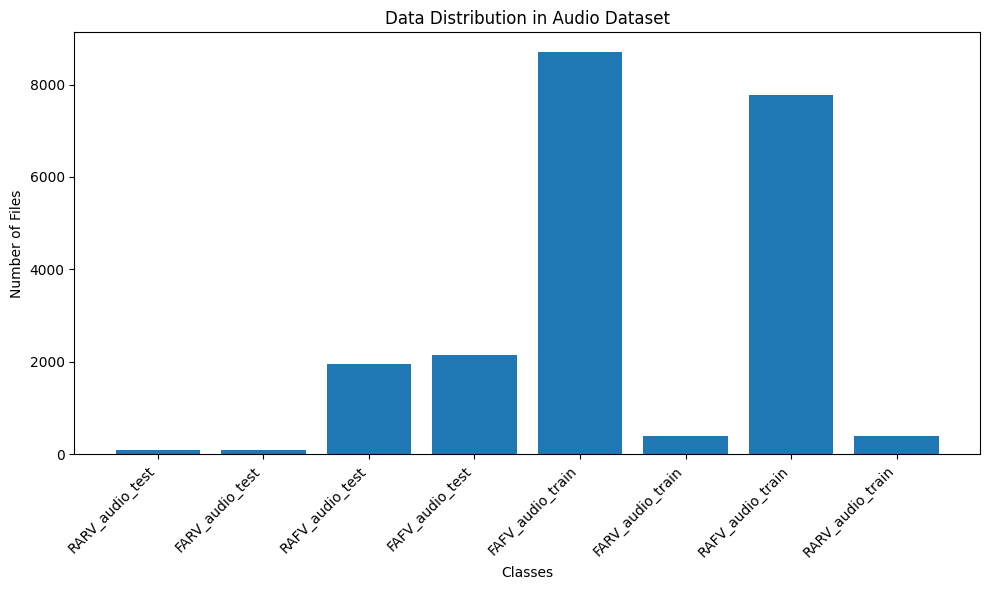

In [37]:
import os
import matplotlib.pyplot as plt

# Path to the audio dataset directory
dataset_path = '/content/drive/MyDrive/audio_files'

# Create a dictionary to store the count of files for each class/folder
class_counts = {}

# Iterate through subfolders in the dataset directory
for root, dirs, files in os.walk(dataset_path):
    for dir_name in dirs:
        class_path = os.path.join(root, dir_name)
        num_files = len([f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))])
        class_counts[dir_name] = num_files

# Extract class names and counts for plotting
class_names = list(class_counts.keys())
counts = list(class_counts.values())

# Create a bar plot to visualize the distribution
plt.figure(figsize=(10, 6))
plt.bar(class_names, counts)
plt.xlabel('Classes')
plt.ylabel('Number of Files')
plt.title('Data Distribution in Audio Dataset')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [4]:
!pip install torch torchvision torchaudio
!pip install transformers  # For Hugging Face AST
!pip install librosa      # For audio preprocessing
!pip install audioread    # For FLAC support

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 94.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [28]:
import librosa
import numpy as np
import torch

def load_and_preprocess_audio(file_path, sr=16000, max_length=10):
    # Load FLAC file
    audio, sample_rate = librosa.load(file_path, sr=sr)
    # Trim or pad to fixed length (10 seconds = 16000 * 10 = 160000 samples)
    target_length = sr * max_length
    if len(audio) > target_length:
        audio = audio[:target_length]
    else:
        audio = np.pad(audio, (0, max(target_length - len(audio), 0)), mode='constant')
    # Compute Mel-spectrogram (128 mel bands, 1024 time frames)
    mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128, n_fft=400, hop_length=160, fmax=8000)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    # Ensure exact size (128, 1024)
    mel_spec_db = librosa.util.fix_length(mel_spec_db, size=1024, axis=1)
    # Normalize
    mel_spec_db = (mel_spec_db - mel_spec_db.mean()) / (mel_spec_db.std() + 1e-8)
    return mel_spec_db



# Example usage
file_path = "/content/drive/MyDrive/audio_dataset_train/FAKE/1_2_id03889_wavtolip.flac"
mel_spec = load_and_preprocess_audio(file_path)
print(mel_spec.shape)

(128, 1024)


In [46]:
import os
import random
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import torch
import librosa
from tqdm import tqdm

class AudioDeepfakeDataset(Dataset):
    def __init__(self, root_dir, cache_dir="/content/drive/MyDrive/spectrograms", fraction=0.25):
        self.root_dir = root_dir
        self.cache_dir = cache_dir

        # Load all files
        real_files_full = [os.path.join(root_dir, "real", f) for f in os.listdir(os.path.join(root_dir, "real")) if f.endswith('.flac')]
        fake_files_full = [os.path.join(root_dir, "fake", f) for f in os.listdir(os.path.join(root_dir, "fake")) if f.endswith('.flac')]

        # Randomly select 1/4th of each class
        random.seed(42)  # For reproducibility
        self.real_files = random.sample(real_files_full, k=int(len(real_files_full) * fraction))
        self.fake_files = random.sample(fake_files_full, k=int(len(fake_files_full) * fraction))

        # Combine and create labels
        self.all_files = self.real_files + self.fake_files
        self.labels = [0] * len(self.real_files) + [1] * len(self.fake_files)

        # Cache spectrograms for the selected files (optional)
        #cache_spectrograms(self.all_files, cache_dir)

    def __len__(self):
        return len(self.all_files)

    def __getitem__(self, idx):
        cache_path = os.path.join(self.cache_dir, f"spec_{idx}.npy")
        if os.path.exists(cache_path):
            mel_spec = np.load(cache_path)
        else:
            mel_spec = load_and_preprocess_audio(self.all_files[idx])
        mel_spec = torch.tensor(mel_spec, dtype=torch.float32).unsqueeze(0)  # (1, 128, 1024)
        label = self.labels[idx]
        return mel_spec, label

# Initialize dataset with 1/4th of each class
dataset = AudioDeepfakeDataset("/content/drive/MyDrive/audio_dataset_custom", fraction=0.25)

In [47]:
from torch.utils.data import DataLoader, random_split

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

In [48]:
from transformers import ASTModel, ASTConfig
import torch.nn as nn

# Load pretrained AST
model = ASTModel.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")
# Modify the classifier head for binary classification
num_labels = 2
model.classifier = nn.Linear(model.config.hidden_size, num_labels)

# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

ASTModel(
  (embeddings): ASTEmbeddings(
    (patch_embeddings): ASTPatchEmbeddings(
      (projection): Conv2d(1, 768, kernel_size=(16, 16), stride=(10, 10))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): ASTEncoder(
    (layer): ModuleList(
      (0-11): 12 x ASTLayer(
        (attention): ASTSdpaAttention(
          (attention): ASTSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
          (output): ASTSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (intermediate): ASTIntermediate(
          (dense): Linear(in_features=768, out_features=3072, bias=True)
          (intermediate_act_fn): GELUAct

In [49]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [51]:
from tqdm import tqdm

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    # Add tqdm to the training loop
    for mel_specs, labels in tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Training"):
        mel_specs, labels = mel_specs.to(device), labels.to(device)

        # Forward pass
        outputs = model(mel_specs)
        # Access the last_hidden_state instead of logits
        loss = criterion(outputs.last_hidden_state[:, 0, :], labels)

        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

    # Evaluate on test set
    model.eval()
    correct = 0
    total = 0
    # Add tqdm to the evaluation loop
    with torch.no_grad():
        for mel_specs, labels in tqdm(test_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Testing"):
            mel_specs, labels = mel_specs.to(device), labels.to(device)
            outputs = model(mel_specs)
            # Access the last_hidden_state for prediction
            _, predicted = torch.max(outputs.last_hidden_state[:, 0, :], 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Test Accuracy: {100 * correct / total:.2f}%")


Epoch [1/10] Training:   0%|          | 0/102 [00:04<?, ?it/s]


KeyboardInterrupt: 